# Dumper Truck Detector — Model Training

Trains a binary image classifier that tells whether a **dumper truck** is present in an image, using transfer learning on top of MobileNetV2 (small and fast enough for CPU inference on a laptop, which matters since the FastAPI backend will run this model on live webcam frames).

**Before running this notebook**, put your training images here:

```
model_training/
  image_data/
    dumper_truck/        <- photos that DO contain a dumper truck
        img001.jpg
        img002.png
        ...
    no_dumper_truck/      <- photos that do NOT contain a dumper truck
        img001.jpg
        ...
```

Guidelines:
- JPEG and PNG (and most common formats) are both fine — mixed is OK.
- Aim for at least ~80-100 images per class if you can; more (and more varied) is better. Very small datasets (a few dozen images) will still run but may overfit.
- For `no_dumper_truck`, include the kinds of things your webcam will actually see when there's *no* dumper truck (your room, other vehicles, empty street, etc.) — the more representative these are, the better the model generalizes to your real webcam feed.
- Try to have a roughly similar number of images in each class.

At the end, this notebook saves:
- `saved_model/dumper_truck_model.keras` — the trained model (Keras v3 native format)
- `saved_model/dumper_truck_model.h5` — the same model in legacy HDF5 format, in case you need it
- `saved_model/class_names.json` — the label order the model was trained with

...and copies those three files into `../backend/saved_model/`, where the FastAPI backend expects them.


In [1]:
import json
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.17.0
GPU available: []


## 1. Configuration

In [2]:
DATA_DIR = Path("image_data")
IMG_SIZE = (224, 224)          # MobileNetV2's native input size
BATCH_SIZE = 16
VALIDATION_SPLIT = 0.2
SEED = 42

INITIAL_EPOCHS = 15            # training just the new classification head
FINE_TUNE_EPOCHS = 10          # additional epochs fine-tuning the top of MobileNetV2
FINE_TUNE_AT_LAYER = 100       # unfreeze layers from this index onward during fine-tuning

SAVED_MODEL_DIR = Path("saved_model")
SAVED_MODEL_DIR.mkdir(exist_ok=True)

BACKEND_SAVED_MODEL_DIR = Path("../backend/saved_model")


## 2. Sanity-check the dataset

Quick check that both class folders exist and have images in them before we spend time training.

In [3]:
for class_name in ["dumper_truck", "no_dumper_truck"]:
    class_dir = DATA_DIR / class_name
    if not class_dir.exists():
        raise FileNotFoundError(
            f"Expected folder not found: {class_dir.resolve()}\n"
            "Create it and add images before continuing (see the instructions above)."
        )
    n_images = len([p for p in class_dir.iterdir() if p.is_file() and not p.name.startswith('.')])
    print(f"{class_name}: {n_images} images")
    if n_images == 0:
        raise ValueError(f"No images found in {class_dir}. Add some images and re-run this cell.")


dumper_truck: 104 images
no_dumper_truck: 118 images


## 3. Load the dataset

`image_dataset_from_directory` infers the two classes from the subfolder names and handles the train/validation split for us. Class indices are assigned alphabetically, so `dumper_truck` -> 0 and `no_dumper_truck` -> 1 — we save this order to `class_names.json` later so the backend always agrees with the model on what each output means, regardless of folder naming.

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
)

class_names = train_ds.class_names
print("Class names (index order):", class_names)


Found 221 files belonging to 2 classes.
Using 177 files for training.
Found 221 files belonging to 2 classes.
Using 44 files for validation.
Class names (index order): ['dumper_truck', 'no_dumper_truck']


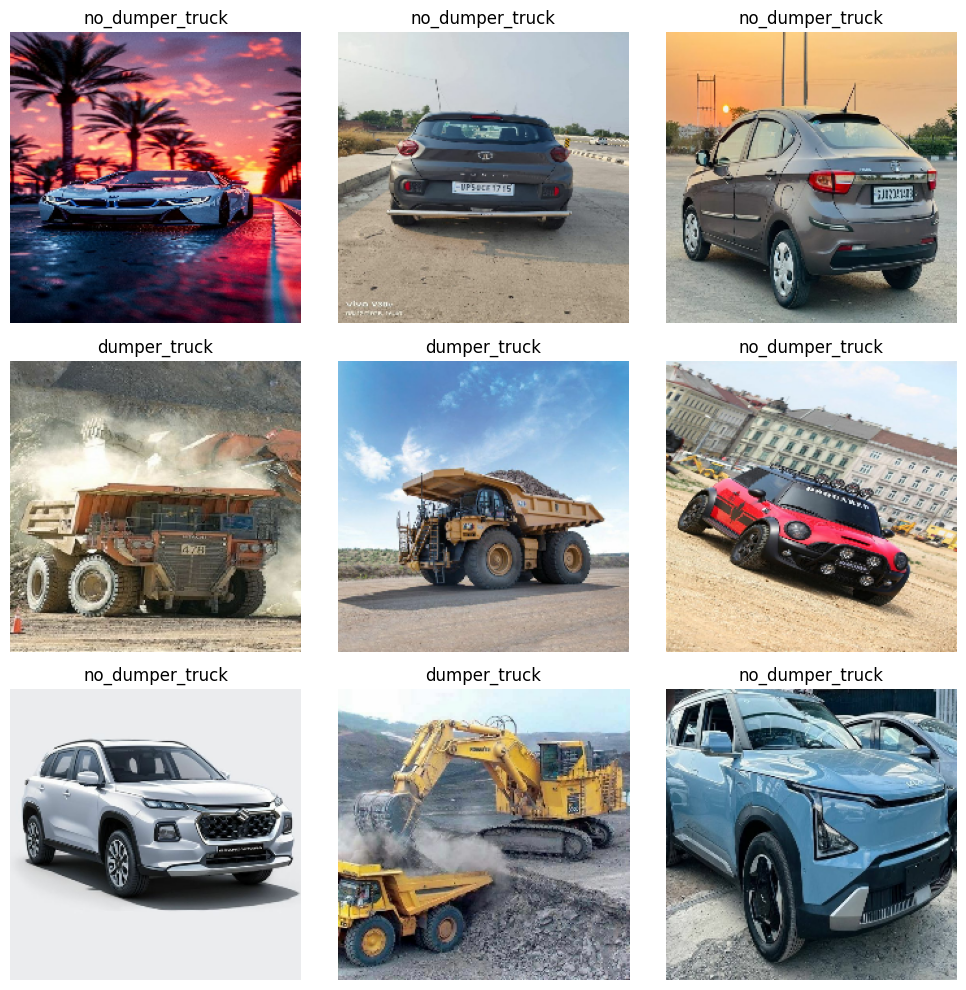

In [5]:
# Peek at a few training images to make sure everything loaded correctly.
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(min(9, images.shape[0])):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i][0])])
        plt.axis("off")
plt.tight_layout()
plt.show()


In [6]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)


## 4. Data augmentation

Helps a lot when the dataset is small — makes the model less sensitive to exact camera angle, lighting, and framing, which matters since it'll be evaluated on a live, ever-changing webcam feed.

In [7]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.15),
    tf.keras.layers.RandomBrightness(0.15),
], name="data_augmentation")


## 5. Build the model

MobileNetV2 pretrained on ImageNet, used as a frozen feature extractor, with a small classification head on top. This trains quickly on CPU and is light enough to run real-time-ish inference on incoming webcam frames.

In [8]:
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Layer (type)             ┃ Output Shape      ┃    Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ input_layer_1            │ (None, 224, 224,  │          0 │
│ (InputLayer)             │ 3)                │            │
├──────────────────────────┼───────────────────┼────────────┤
│ data_augmentation        │ (None, 224, 224,  │          0 │
│ (Sequential)             │ 3)                │            │
├──────────────────────────┼───────────────────┼────────────┤
│ true_divide (TrueDivide) │ (None, 224, 224,  │          0 │
│                          │ 3)                │            │
├──────────────────────────┼───────────────────┼────────────┤
│ subtract (Subtract)      │ (None, 224, 224,  │          0 │
│                          │ 3)                │            │
├──────────────────────────┼───────────────────┼────────────┤
│ mobilenetv2_1.00_224     │ (None, 7, 7,      │  2,257,984 │
│ (Functional)             │ 1280)             │            │
├──────────────────────────┼───────────────────┼────────────┤
│ global_average_pooling2d │ (None, 1280)      │          0 │
│ (GlobalAveragePooling2D) │                   │            │
├──────────────────────────┼───────────────────┼────────────┤
│ dropout (Dropout)        │ (None, 1280)      │          0 │
├──────────────────────────┼───────────────────┼────────────┤
│ dense (Dense)            │ (None, 1)         │      1,281 │
└──────────────────────────┴───────────────────┴────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 6. Train the classification head

Only the new top layers are trainable so far — the MobileNetV2 base stays frozen.

In [9]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS,
    callbacks=callbacks,
)


Epoch 1/15


C:\Users\choud\dumper-truck-detector\model_training\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 354ms/step - accuracy: 0.5480 - loss: 0.7109 - val_accuracy: 0.9091 - val_loss: 0.3532
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 213ms/step - accuracy: 0.8870 - loss: 0.3586 - val_accuracy: 0.9773 - val_loss: 0.2091
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 212ms/step - accuracy: 0.9040 - loss: 0.2278 - val_accuracy: 0.9773 - val_loss: 0.1451
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 223ms/step - accuracy: 0.9605 - loss: 0.1788 - val_accuracy: 0.9773 - val_loss: 0.1136
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 220ms/step - accuracy: 0.9774 - loss: 0.1535 - val_accuracy: 1.0000 - val_loss: 0.0912
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 216ms/step - accuracy: 0.9661 - loss: 0.1358 - val_accuracy: 1.0000 - val_loss: 0.0780
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 220ms/step - accuracy: 0.9831 - loss: 0.1140 - val_accuracy: 1.0000 - val_loss: 0.0685
Epoch 8/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 218ms/step - accuracy: 0.9774 - loss: 0.0977 - val_accuracy: 1.0000 - val_

## 7. Fine-tune the top of MobileNetV2 (optional but recommended)

Unfreezes the later layers of the base model and continues training with a much lower learning rate. This usually gives a meaningful accuracy boost once the head has already learned something reasonable. If you have a very small dataset and see validation loss get worse here, skip this step and just use the model from step 6.

In [10]:
base_model.trainable = True

for layer in base_model.layers[:FINE_TUNE_AT_LAYER]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

total_epochs = INITIAL_EPOCHS + FINE_TUNE_EPOCHS

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1] + 1,
    callbacks=callbacks,
)


Epoch 16/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 424ms/step - accuracy: 0.9661 - loss: 0.1612 - val_accuracy: 1.0000 - val_loss: 0.0273
Epoch 17/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 280ms/step - accuracy: 0.9718 - loss: 0.1463 - val_accuracy: 1.0000 - val_loss: 0.0261
Epoch 18/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 322ms/step - accuracy: 0.9661 - loss: 0.1582 - val_accuracy: 1.0000 - val_loss: 0.0245
Epoch 19/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 313ms/step - accuracy: 0.9831 - loss: 0.1117 - val_accuracy: 1.0000 - val_loss: 0.0237
Epoch 20/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 320ms/step - accuracy: 0.9435 - loss: 0.1353 - val_accuracy: 1.0000 - val_loss: 0.0224
Epoch 21/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 334ms/step - accuracy: 0.9831 - loss: 0.1008 - val_accuracy: 1.0000 - val_loss: 0.0214
Epoch 22/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 327ms/step - accuracy: 0.9774 - loss: 0.0890 - val_accuracy: 1.0000 - val_loss: 0.0204
Epoch 23/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 299ms/step - accuracy: 0.9831 - loss: 0.1006 - val_acc

## 8. Review training curves

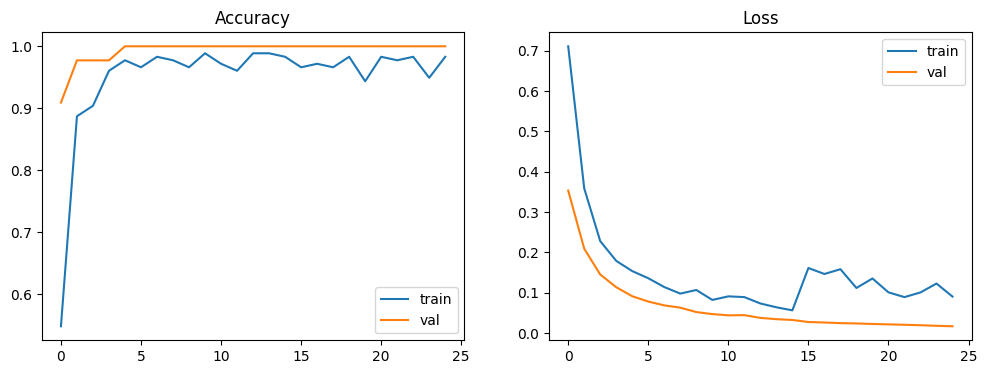

In [11]:
def plot_history(*histories):
    acc, val_acc, loss, val_loss = [], [], [], []
    for h in histories:
        acc += h.history.get("accuracy", [])
        val_acc += h.history.get("val_accuracy", [])
        loss += h.history.get("loss", [])
        val_loss += h.history.get("val_loss", [])

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(acc, label="train")
    plt.plot(val_acc, label="val")
    plt.title("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(loss, label="train")
    plt.plot(val_loss, label="val")
    plt.title("Loss")
    plt.legend()
    plt.show()

plot_history(history, history_fine)


## 9. Evaluate

Confusion matrix and a classification report, so you know where the model is still making mistakes and whether you need more training data for a particular class.

In [12]:
y_true = np.concatenate([labels.numpy() for _, labels in val_ds], axis=0).ravel()
y_pred_proba = model.predict(val_ds, verbose=0).ravel()
y_pred = (y_pred_proba >= 0.5).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix (rows=true, cols=predicted):")
print(cm)


                 precision    recall  f1-score   support

   dumper_truck       0.42      0.42      0.42        19
no_dumper_truck       0.56      0.56      0.56        25

       accuracy                           0.50        44
      macro avg       0.49      0.49      0.49        44
   weighted avg       0.50      0.50      0.50        44

Confusion matrix (rows=true, cols=predicted):
[[ 8 11]
 [11 14]]


## 10. Save the model

Saves both `.keras` (recommended, native Keras v3 format) and `.h5` (legacy format, in case some tool you use only reads HDF5), plus the class name order so the backend can map predictions back to labels correctly.

In [14]:
model.save(SAVED_MODEL_DIR / "dumper_truck_model.keras")
model.save(SAVED_MODEL_DIR / "dumper_truck_model.keras")

with open(SAVED_MODEL_DIR / "class_names.json", "w") as f:
    json.dump(class_names, f)

print("Saved to:", SAVED_MODEL_DIR.resolve())
print("Class names:", class_names)


Saved to: C:\Users\choud\dumper-truck-detector\model_training\saved_model
Class names: ['dumper_truck', 'no_dumper_truck']


## 11. Copy the model into the backend

The FastAPI backend loads its model from `backend/saved_model/`. This copies the freshly trained files there so the API picks them up on its next restart.

In [15]:
BACKEND_SAVED_MODEL_DIR.mkdir(parents=True, exist_ok=True)

for filename in ["dumper_truck_model.keras", "class_names.json"]:
    shutil.copy(SAVED_MODEL_DIR / filename, BACKEND_SAVED_MODEL_DIR / filename)
print("Copied model files to:", BACKEND_SAVED_MODEL_DIR.resolve())
print("Restart (or start) the FastAPI backend to pick up the new model.")


Copied model files to: C:\Users\choud\dumper-truck-detector\backend\saved_model
Restart (or start) the FastAPI backend to pick up the new model.


## 12. Quick manual test (optional)

Run a single image (e.g. one you didn't train on) through the saved model to sanity-check predictions before wiring up the live webcam feed.

In [16]:
def predict_image(image_path: str):
    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    arr = tf.keras.utils.img_to_array(img)
    arr = tf.expand_dims(arr, 0)
    proba = model.predict(arr, verbose=0)[0][0]
    predicted_index = 1 if proba >= 0.5 else 0
    print(f"Prediction: {class_names[predicted_index]}  (raw sigmoid output: {proba:.4f})")

# Example usage - replace with a real path to try it:
# predict_image("image_data/dumper_truck/some_test_image.jpg")
